# Analyse des topics BERTopic dans les chats Telegram

Ce notebook prolonge le topic modelling effectué sur le corpus Telegram. Il ne sert plus à entraîner le modèle BERTopic, mais à interpréter les topics déjà obtenus, en particulier la version réduite à 80 topics.

L’objectif est d’utiliser la classification thématique comme outil de navigation dans les messages : repérer les topics, revenir aux messages et à leur contexte, puis regrouper les topics en grandes thématiques interprétables. Cette étape permet de passer d’une sortie automatique du modèle à une analyse qualitative et quantitative des formes d’entraide, des besoins administratifs et matériels, ainsi que des tensions exprimées dans les chats.

## 1. Chargement du corpus annoté par BERTopic

Cette première cellule charge le fichier CSV produit lors de l’étape précédente. Chaque ligne correspond à un message Telegram auquel BERTopic a attribué un topic, ici dans la colonne `bertopic_topic_reduced_80`.

Ce fichier sert de base à l’analyse : il contient à la fois les métadonnées des messages, le texte nettoyé et les topics calculés par le modèle.

In [ ]:
import pandas as pd

df = pd.read_csv(
    "/Users/quentinnippert/Documents/mm_files/Telegram_analyse/BERTopic/chats/first_model_reduced_compare/tables/messages_with_topics_reduced_80.csv"
)

df.head()

## 2. Retour qualitatif aux messages et à leur contexte

Avant de regrouper les topics, le notebook prévoit plusieurs outils de vérification qualitative. Ces fonctions permettent de rechercher un fragment de message, d’afficher des exemples aléatoires pour un topic donné et, lorsque c’est nécessaire, de retrouver le contexte conversationnel dans les fichiers JSON Telegram originaux.

Cette étape est importante, car les topics ne sont pas interprétés uniquement à partir des mots-clés produits par le modèle : l’interprétation repose aussi sur un retour aux messages concrets et à leur environnement de discussion.

### 2.1. Recherche d’un fragment dans le corpus

Cette cellule permet de rechercher un mot ou une expression dans la colonne `text_clean`. Elle sert à repérer rapidement des messages liés à un thème précis ou à vérifier la présence d’un fragment dans un chat particulier.

In [ ]:
fragment = "война"

result = df[
    df["text_clean"]
    .astype(str)
    .str.contains(fragment, case=False, na=False, regex=False)
]

#seulement lines where bertopic_topic_reduced_80 = 61

result = result[result["file"] == "armiya_krasotok"]

### 2.2. Affichage d’exemples aléatoires par topic

La fonction suivante imprime un échantillon de messages associés à un topic BERTopic donné. Elle permet de vérifier la cohérence interne du topic et de comprendre le type de messages qui le composent.

In [6]:
import pandas as pd
import textwrap

def print_random_messages_by_topic(
    df,
    topic_num,
    topic_col="bertopic_topic_reduced_80",
    text_col="text_clean",
    n=20,
    random_state=None,
    width=120
):
    # фильтруем нужный топик
    subset = df[df[topic_col] == topic_num].copy()

    if subset.empty:
        print(f"Нет сообщений для топика {topic_num}")
        return

    # если сообщений меньше 20 — берем сколько есть
    sample_size = min(n, len(subset))

    sample = subset.sample(
        n=sample_size,
        random_state=random_state
    )

    print("=" * width)
    print(f"TOPIC {topic_num} | найдено сообщений: {len(subset)} | показываю: {sample_size}")
    print("=" * width)

    for i, (_, row) in enumerate(sample.iterrows(), 1):
        chat_name = row.get("chat_name", "")
        date = row.get("date", "")
        sender = row.get("from", "")
        message_id = row.get("message_id", "")
        text = str(row.get(text_col, ""))

        print(f"\n[{i}] chat: {chat_name}")
        print(f"date: {date} | from: {sender} | message_id: {message_id}")
        print("-" * width)

        wrapped_text = textwrap.fill(
            text,
            width=width,
            replace_whitespace=False,
            break_long_words=False
        )

        print(wrapped_text)
        print("-" * width)

### 2.3. Recherche du contexte conversationnel dans les fichiers JSON

Ces fonctions permettent de retrouver un message dans les exports JSON originaux des chats Telegram et d’afficher les messages précédents et suivants. Elles servent à replacer un message dans son fil de discussion, ce qui est particulièrement utile pour les messages ambigus ou fortement dépendants du contexte.

In [11]:
from pathlib import Path
import json
import re
import textwrap
import pandas as pd


def normalize_text(text):
    """Нормализация текста для поиска."""
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def telegram_text_to_str(text):
    """
    Telegram JSON иногда хранит text как строку,
    а иногда как список строк и dict-объектов.
    """
    if text is None:
        return ""

    if isinstance(text, str):
        return text

    if isinstance(text, list):
        parts = []
        for item in text:
            if isinstance(item, str):
                parts.append(item)
            elif isinstance(item, dict):
                parts.append(str(item.get("text", "")))
        return "".join(parts)

    return str(text)


def find_rows_by_words(
    df,
    query,
    text_col="text_clean",
    mode="all_words"
):
    """
    mode="all_words" — ищет строки, где есть все слова из query
    mode="phrase" — ищет точный фрагмент
    """

    query_norm = normalize_text(query)

    if mode == "phrase":
        mask = (
            df[text_col]
            .astype(str)
            .str.lower()
            .str.contains(query_norm, na=False, regex=False)
        )

    elif mode == "all_words":
        words = query_norm.split()
        texts = df[text_col].astype(str).map(normalize_text)

        mask = texts.apply(
            lambda x: all(word in x for word in words)
        )

    else:
        raise ValueError("mode должен быть 'all_words' или 'phrase'")

    return df[mask].copy()

In [12]:
def print_message_context_from_json(
    df,
    query,
    chats_dir="chats",
    text_col="text_clean",
    file_col="file",
    relative_path_col="relative_path",
    message_id_col="message_id",
    context_size=10,
    candidate_idx=0,
    mode="all_words",
    width=120
):
    """
    1. Ищет строку в df по словам / фрагменту из text_clean
    2. Берет название json-файла из колонки file
    3. Ищет этот json в подпапках chats
    4. Находит сообщение внутри json
    5. Печатает контекст +- context_size сообщений
    """

    # 1. Ищем строки в df
    matches = find_rows_by_words(
        df=df,
        query=query,
        text_col=text_col,
        mode=mode
    )

    if matches.empty:
        print("Ничего не найдено в df по этому запросу.")
        return None

    print(f"Найдено строк в df: {len(matches)}")

    # Берем одну найденную строку
    row = matches.iloc[candidate_idx]

    filename = row[file_col]
    message_id = row.get(message_id_col, None)

    print("=" * width)
    print("НАЙДЕННАЯ СТРОКА В DF")
    print("=" * width)
    print(f"candidate_idx: {candidate_idx}")
    print(f"file: {filename}")
    print(f"chat_name: {row.get('chat_name', '')}")
    print(f"message_id: {message_id}")
    print(f"date: {row.get('date', '')}")
    print("-" * width)
    print(textwrap.fill(str(row[text_col]), width=width))
    print("=" * width)

    chats_dir = Path(chats_dir)

    # 2. Сначала пробуем найти файл через relative_path, если колонка есть
    json_path = None

    if relative_path_col in df.columns and pd.notna(row.get(relative_path_col, None)):
        possible_path = chats_dir / row[relative_path_col]
        if possible_path.exists():
            json_path = possible_path

    # 3. Если не нашли через relative_path — ищем по имени файла во всех подпапках chats
    if json_path is None:
        found_files = list(chats_dir.rglob(filename))

        if not found_files:
            print(f"Файл {filename} не найден внутри папки {chats_dir}")
            return None

        if len(found_files) > 1:
            print(f"Найдено несколько файлов с именем {filename}, беру первый:")
            for p in found_files:
                print(" -", p)

        json_path = found_files[0]

    print(f"\nJSON файл найден: {json_path}")

    # 4. Открываем json
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    messages = data.get("messages", [])

    if not messages:
        print("В JSON нет поля messages или оно пустое.")
        return None

    # 5. Ищем сообщение внутри json
    target_index = None

    # Сначала надежнее искать по message_id
    if pd.notna(message_id):
        for i, msg in enumerate(messages):
            if msg.get("id") == int(message_id):
                target_index = i
                break

    # Если по id не нашли — ищем по тексту
    if target_index is None:
        query_norm = normalize_text(query)

        for i, msg in enumerate(messages):
            msg_text = telegram_text_to_str(msg.get("text", ""))
            msg_text_norm = normalize_text(msg_text)

            if mode == "phrase":
                if query_norm in msg_text_norm:
                    target_index = i
                    break

            elif mode == "all_words":
                words = query_norm.split()
                if all(word in msg_text_norm for word in words):
                    target_index = i
                    break

    if target_index is None:
        print("Сообщение не найдено внутри JSON.")
        return None

    # 6. Берем контекст
    start = max(0, target_index - context_size)
    end = min(len(messages), target_index + context_size + 1)

    context_messages = messages[start:end]

    print("\n" + "=" * width)
    print(f"КОНТЕКСТ: {context_size} сообщений до и {context_size} после")
    print(f"Позиция сообщения в JSON: {target_index}")
    print("=" * width)

    context_rows = []

    for i, msg in enumerate(context_messages, start=start):
        is_target = i == target_index

        msg_id = msg.get("id", "")
        msg_date = msg.get("date", "")
        msg_from = msg.get("from", msg.get("from_id", ""))
        msg_type = msg.get("type", "")
        msg_text = telegram_text_to_str(msg.get("text", ""))

        marker = ">>> TARGET MESSAGE <<<" if is_target else ""

        print("\n" + ("#" * width if is_target else "-" * width))
        print(f"{marker}")
        print(f"index_in_json: {i} | id: {msg_id} | date: {msg_date} | from: {msg_from} | type: {msg_type}")
        print("-" * width)

        if msg_text.strip():
            print(textwrap.fill(msg_text, width=width, replace_whitespace=False))
        else:
            print("[no text]")

        context_rows.append({
            "index_in_json": i,
            "is_target": is_target,
            "id": msg_id,
            "date": msg_date,
            "from": msg_from,
            "type": msg_type,
            "text": msg_text,
            "json_path": str(json_path)
        })

    print("\n" + "=" * width)

    return pd.DataFrame(context_rows)

### 2.4. Exemples de vérification qualitative

Les cellules suivantes appliquent les fonctions précédentes à des topics ou fragments précis. Elles servent de tests ponctuels pour comprendre le contenu d’un topic et vérifier l’interprétation proposée.

In [ ]:
print_random_messages_by_topic(df, topic_num=38)

In [ ]:
context_df = print_message_context_from_json(
    df=df,
    query="Не стану рисковать,несколько раз",
    chats_dir="chats",
    context_size=20,
    mode="all_words"
)

In [ ]:
context_df = print_message_context_from_json(
    df=df,
    query="И в дальнейшем тоже будут просить....потому что война...забрала ВСЁ!!! И нет в этом у людей никакого понимания...лишили",
    chats_dir="chats",
    context_size=150,
    mode="all_words"
)

## 3. Regroupement manuel des topics en grandes thématiques

Après l’examen qualitatif des topics, certains topics BERTopic sont regroupés manuellement en catégories plus larges. Ce regroupement permet de rendre les résultats plus lisibles et de passer d’une classification très fine à des ensembles thématiques interprétables.

Les grandes thématiques portent notamment sur les documents et statuts administratifs, le logement, l’aide sociale, la santé, les enfants et l’école, l’aide humanitaire, le travail, les tensions émotionnelles, la filtration, les fraudes et les services bancaires ou numériques.

In [14]:
topic_to_big_theme = {
    0: "Legal status and documents",
    1: "Legal status and documents",
    18: "Legal status and documents",
    30: "Legal status and documents",
    66: "Legal status and documents",
    75: "Legal status and documents",

    2: "Housing and accommodation",
    35: "Housing and accommodation",
    51: "Housing and accommodation",
    62: "Housing and accommodation",

    4: "Social assistance and benefits",

    16: "Healthcare and public services",
    23: "Healthcare and public services",
    26: "Healthcare and public services",

    17: "Family, children, and schooling",
    59: "Family, children, and schooling",
    72: "Family, children, and schooling",

    13: "Humanitarian and material aid",
    20: "Humanitarian and material aid",
    22: "Humanitarian and material aid",
    41: "Humanitarian and material aid",
    45: "Humanitarian and material aid",
    76: "Humanitarian and material aid",

    5: "Employment and work",
    14: "Employment and work",
    42: "Employment and work",

    9: "Tensions and emotional stress",
    21: "Tensions and emotional stress",
    60: "Tensions and emotional stress",
    61: "Tensions and emotional stress",

    77: "Filtration",
    38: "Fraud",

    40: "Banking, digital services, and currency exchange",
    46: "Banking, digital services, and currency exchange",
    49: "Banking, digital services, and currency exchange",
    58: "Banking, digital services, and currency exchange",
    73: "Banking, digital services, and currency exchange",
    78: "Banking, digital services, and currency exchange",
}

## 4. Distribution des grandes thématiques

Cette section calcule la part de chaque grande thématique dans les messages classés. Le graphique permet d’observer quels types de sujets dominent dans les chats Telegram et de comparer le poids relatif des différentes catégories issues du regroupement des topics.

In [15]:
# --- 2. Выбор колонки с BERTopic ---
# Можно заменить на 'bertopic_topic_general' или 'bertopic_topic_soft'
topic_col = "bertopic_topic_reduced_80"

df_plot = df.copy()

df_plot["big_theme"] = df_plot[topic_col].map(topic_to_big_theme)

# Убираем нерелевантные темы: -1 и темы, которые не вошли в список крупных тем
df_plot = df_plot.dropna(subset=["big_theme"])

# --- 3. График 1: процентное распределение крупных тем ---

theme_percent = (
    df_plot["big_theme"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))
theme_percent.plot(kind="barh")

plt.xlabel("Percentage of messages (%)")
plt.ylabel("Major theme")
plt.title("Distribution of themes in Telegram chats")
plt.tight_layout()
plt.savefig("distribution_major_themes.png", dpi=300, bbox_inches="tight")
plt.show()



NameError: name 'plt' is not defined

### 4.1. Vérification de la part du thème « Filtration »

Cette cellule extrait spécifiquement la part des messages associés au thème de la filtration. Elle permet de mesurer le poids de ce thème par rapport à l’ensemble des messages classés dans les grandes thématiques.

In [ ]:
filtration_percent = theme_percent.get("Filtration", 0)

print(f"Filtration: {filtration_percent:.4f}%")

Filtration: 0.0471%


## 5. Évolution temporelle des grandes thématiques

Cette visualisation représente la distribution mensuelle des grandes thématiques dans le corpus. Elle permet d’observer comment les préoccupations discutées dans les chats évoluent dans le temps : documents, logement, aide matérielle, emploi, santé, tensions émotionnelles ou autres besoins pratiques.

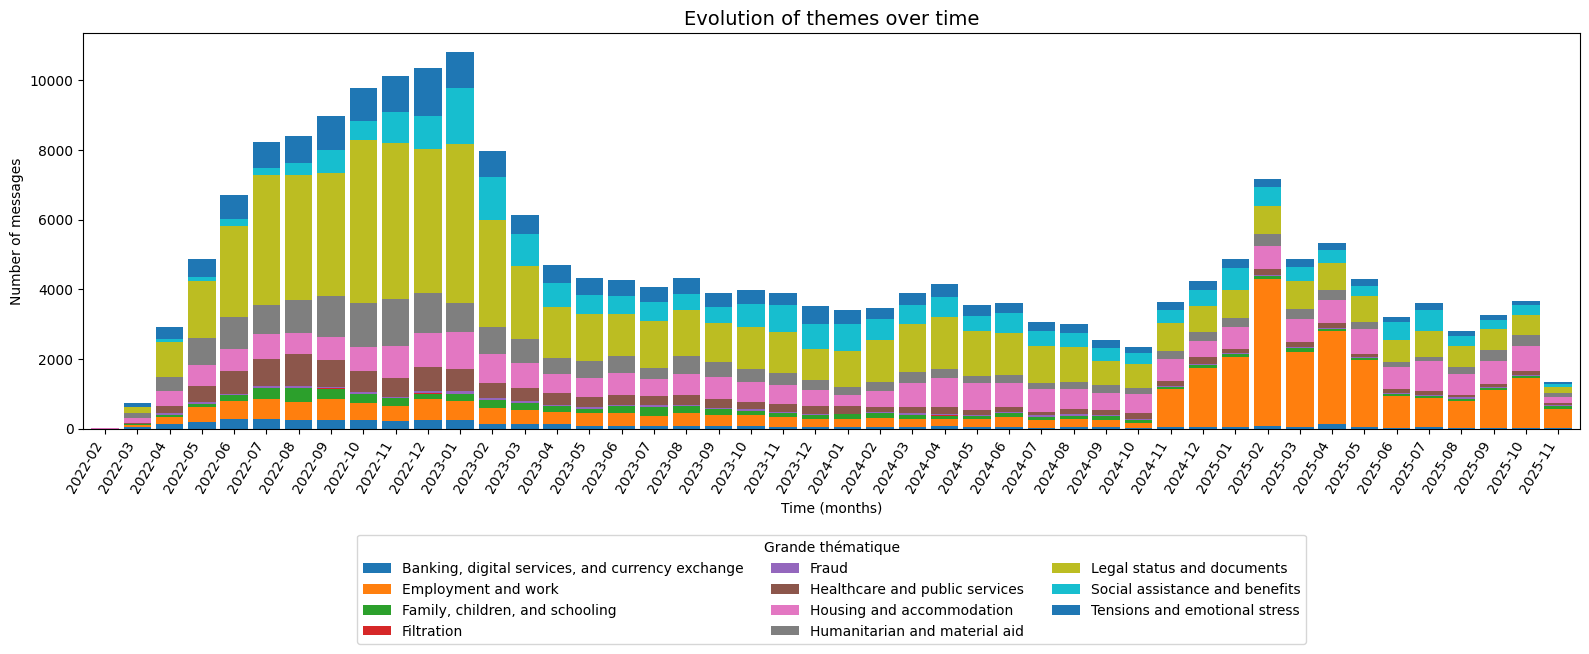

In [ ]:
topic_col = "bertopic_topic_reduced_80"

df_plot = df.copy()
df_plot["date"] = pd.to_datetime(df_plot["date"], errors="coerce")
df_plot = df_plot.dropna(subset=["date"])

df_plot["big_theme"] = df_plot[topic_col].map(topic_to_big_theme)

# =========================
# 2. Version 1: только выбранные grandes thématiques
# =========================

df_themes = df_plot.dropna(subset=["big_theme"]).copy()

# По месяцам
df_themes["period"] = df_themes["date"].dt.to_period("M").dt.to_timestamp()

time_distribution = (
    df_themes
    .groupby(["period", "big_theme"])
    .size()
    .unstack(fill_value=0)
)

ax = time_distribution.plot(
    kind="bar",
    stacked=True,
    figsize=(16, 7),
    width=0.85
)

ax.set_title("Evolution of themes over time", fontsize=14)
ax.set_xlabel("Time (months)")
ax.set_ylabel("Number of messages")

# подписи дат без времени: YYYY-MM
ax.set_xticklabels(
    [d.strftime("%Y-%m") for d in time_distribution.index],
    rotation=60,
    ha="right"
)

# легенда снизу
ax.legend(
    title="Grande thématique",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=3,
    frameon=True
)

plt.tight_layout()
plt.savefig("evolution_grandes_thematiques.png", dpi=300, bbox_inches="tight")
plt.show()

### 5.1. Évolution temporelle avec les messages non regroupés

Cette version du graphique inclut également les messages dont le topic n’a pas été intégré dans les grandes thématiques retenues. La catégorie `Autres messages` permet de situer les thèmes interprétés par rapport au volume total du corpus.

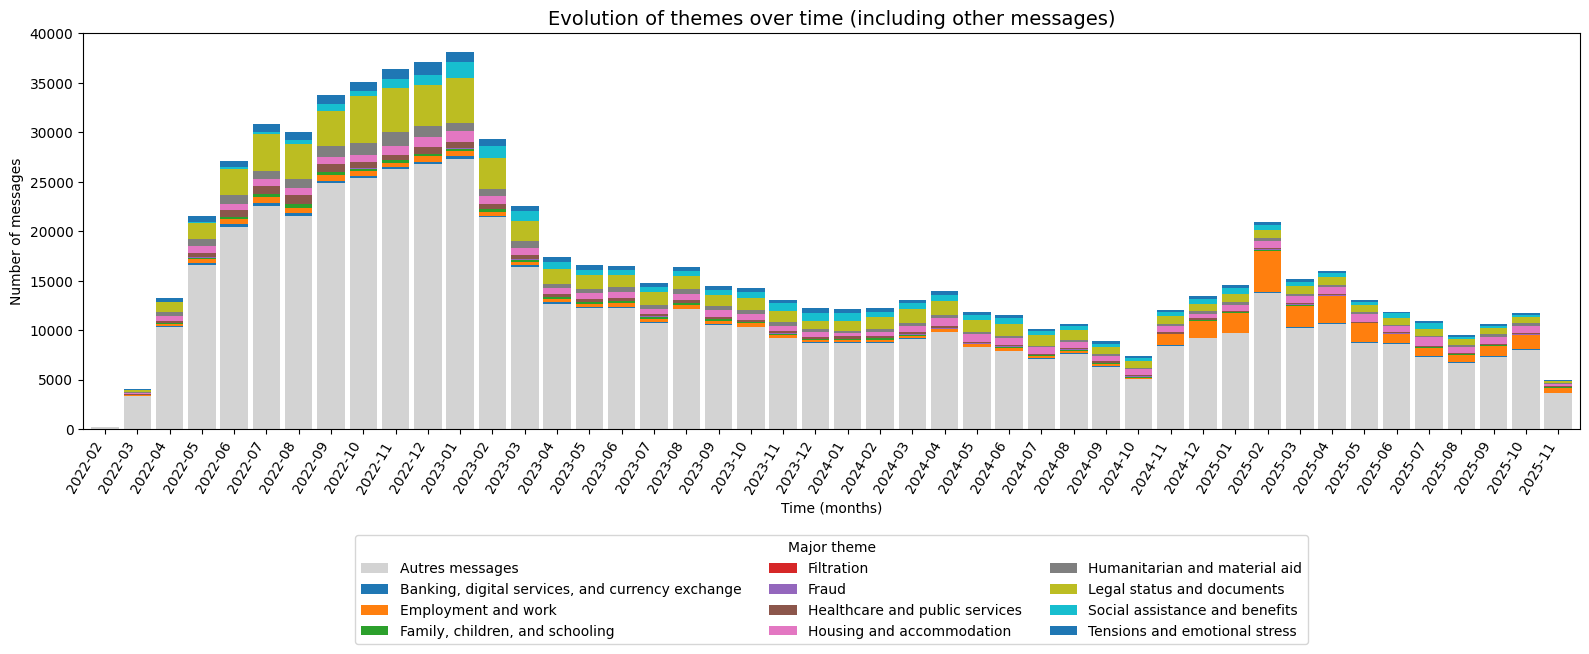

In [ ]:
df_all = df_plot.copy()

df_all["big_theme_with_other"] = df_all["big_theme"].fillna("Autres messages")

df_all["period"] = df_all["date"].dt.to_period("M").dt.to_timestamp()

time_distribution_other = (
    df_all
    .groupby(["period", "big_theme_with_other"])
    .size()
    .unstack(fill_value=0)
)

# ставим Autres messages первым, чтобы серый слой был внизу
cols = list(time_distribution_other.columns)
if "Autres messages" in cols:
    cols = ["Autres messages"] + [c for c in cols if c != "Autres messages"]
    time_distribution_other = time_distribution_other[cols]



# цвета для всех колонок
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

colors = []
i = 0

for col in time_distribution_other.columns:
    if col == "Autres messages":
        colors.append("lightgrey")
    else:
        colors.append(default_colors[i % len(default_colors)])
        i += 1

ax = time_distribution_other.plot(
    kind="bar",
    stacked=True,
    figsize=(16, 7),
    width=0.85,
    color=colors
)

ax.set_title(
    "Evolution of themes over time (including other messages)",
    fontsize=14
)
ax.set_xlabel("Time (months)")
ax.set_ylabel("Number of messages")

ax.set_xticklabels(
    [d.strftime("%Y-%m") for d in time_distribution_other.index],
    rotation=60,
    ha="right"
)

ax.legend(
    title="Major theme",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=3,
    frameon=True
)

plt.tight_layout()
plt.savefig("evolution_major_themes_with_other.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Recherche ciblée : passeports et citoyenneté russe

La dernière partie du notebook effectue une recherche ciblée sur les messages mentionnant les passeports, la citoyenneté ou l’obtention de documents russes. Elle permet d’extraire un sous-ensemble de messages pour une analyse qualitative plus précise des discussions administratives liées au statut juridique et à la naturalisation.

In [ ]:
# Ключевые слова
keywords = [
    'паспорт',
    'паспорта',
    'паспортом',
    'гражданство',
    'гражданства',
    'гражданин',
    'гражданка',
    'российский паспорт',
    'паспорт рф',
    'получил паспорт',
    'получила паспорт',
    'получение гражданства'
]

# Создаем регулярное выражение
pattern = '|'.join(keywords)

# Фильтрация
citizenship_msgs = df[
    df['text_clean'].str.contains(pattern, case=False, na=False)
]

print(f'Найдено сообщений: {len(citizenship_msgs)}\n')

# Вывод первых 50 сообщений полностью
for i, row in citizenship_msgs.head(50).iterrows():
    print('=' * 100)
    print(f"Дата: {row['date']}")
    print(f"Чат: {row['chat_name']}")
    print(f"Автор: {row['from']}")
    print()
    print(row['text_clean'])
    print()

### 7.1. Recherche élargie par expressions régulières

Cette cellule élargit la recherche à différentes formes lexicales autour de `гражданство`, `паспорт`, `паспорт РФ` et des formulations liées à l’obtention ou à l’enregistrement des documents. Elle permet de repérer davantage de messages pertinents malgré la variation linguistique des discussions Telegram.

In [ ]:
pattern = (
    r'гражданств\w*|'
    r'получ\w+\s+паспорт|'
    r'получ\w+\s+гражданств\w*|'
    r'оформ\w+\s+паспорт|'
    r'сделал\w*\s+паспорт|'
    r'российск\w+\s+паспорт|'
    r'паспорт\s+рф|'
    r'гражданин\s+россии|'
    r'получил\s+рф'
)

citizenship_msgs = df[
    df['text_clean'].str.contains(pattern, case=False, na=False, regex=True)
]

for text in citizenship_msgs['text_clean'].head(100):
    print('\n' + '='*100)
    print(text)